# Reward Model Debug

In [2]:
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from stable_baselines3 import PPO

import sumo_rl_ego as sre
from human_feedback_rl.common.trajectory_generators import TrajectoryGeneratorFromAgent

from loadings import load_reward_ensemble
from plot_functions import plot_scatter, plot_scatter_all_models, plot_reward_curves

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

Plot functions loaded OK


In [3]:
RUN_DIR = Path("/Users/andreazhang/Desktop/newTesi/sumo-human-feedback-rl/outputs/ppo_demo_irl seed=0_01")

import sumo_gym_ego.core.simulation as _sim_mod
import traci as _traci_mod
_sim_mod.load_traci = lambda use_gui: _traci_mod

try:
    env.close()
except Exception:
    pass

env = sre.make_vec_env(
    "HighwayEgo-v0",
    n_envs=4,
    base_seed=0,
    ego="continuous",
    reward="fast"
)

checkpoint_dirs = sorted(RUN_DIR.glob("checkpoint_*"))

reward_models_list = []
agents_list = []

for ckpt_dir in checkpoint_dirs:
    reward_model = load_reward_ensemble(
        ckpt_dir / "reward_model.pt",
        env.observation_space,
        env.action_space,
    )
    agents = PPO.load(
        ckpt_dir / "agent.zip", 
        env=env, 
        device="cpu"
    )
    reward_models_list.append(reward_model)
    agents_list.append(agents)

print(f"Loaded {len(agents_list)} checkpoints: {[d.name for d in checkpoint_dirs]}")

Loaded 10 checkpoints: ['checkpoint_0010', 'checkpoint_0020', 'checkpoint_0030', 'checkpoint_0040', 'checkpoint_0050', 'checkpoint_0060', 'checkpoint_0070', 'checkpoint_0080', 'checkpoint_0090', 'checkpoint_0100']


In [4]:
ID = 9
N_STEPS = 100000

trajectory_generator = TrajectoryGeneratorFromAgent(
    agent=agents_list[ID],
    reward_model=reward_models_list[ID],
    venv=env,
)

trajectories = trajectory_generator.sample(N_STEPS)

In [5]:
# next_status: 7-dim one-hot [arrived, collided, off_road, timeout, running, teleported, removed_unknown]
STATUS_ARRIVED  = 0
STATUS_COLLIDED = 1
STATUS_OFFROAD  = 2
STATUS_TIMEOUT  = 3
STATUS_RUNNING  = 4

terminal_statuses = [np.argmax(traj[-1].next_status) for traj in trajectories]

n_episodes = len(trajectories)
n_arrived  = sum(s == STATUS_ARRIVED  for s in terminal_statuses)
n_collided = sum(s == STATUS_COLLIDED for s in terminal_statuses)
n_offroad  = sum(s == STATUS_OFFROAD  for s in terminal_statuses)
n_timeout  = sum(s == STATUS_TIMEOUT  for s in terminal_statuses)

print(f"Episodi totali:        {n_episodes}")
print()
print(f"Terminazioni:")
print(f"  Arrived:  {n_arrived:3d}  ({100 * n_arrived  / n_episodes:.1f}%)")
print(f"  Collided: {n_collided:3d}  ({100 * n_collided / n_episodes:.1f}%)")
print(f"  Off-road: {n_offroad:3d}  ({100 * n_offroad  / n_episodes:.1f}%)")
print(f"  Timeout:  {n_timeout:3d}  ({100 * n_timeout  / n_episodes:.1f}%)")

Episodi totali:        600

Terminazioni:
  Arrived:  450  (75.0%)
  Collided: 150  (25.0%)
  Off-road:   0  (0.0%)
  Timeout:    0  (0.0%)


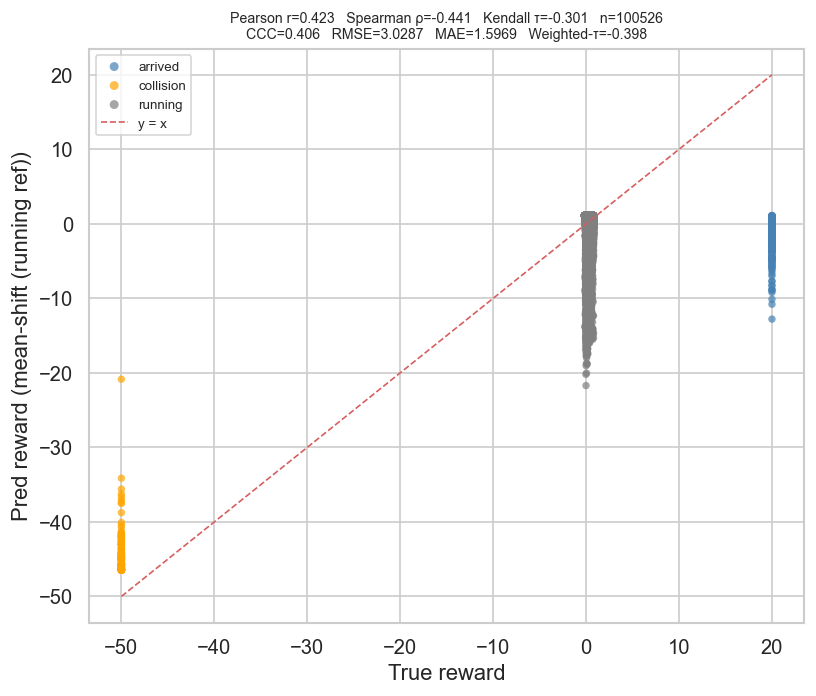

(<Figure size 840x720 with 1 Axes>,
 <Axes: title={'center': 'Pearson r=0.423   Spearman ρ=-0.441   Kendall τ=-0.301   n=100526\nCCC=0.406   RMSE=3.0287   MAE=1.5969   Weighted-τ=-0.398'}, xlabel='True reward', ylabel='Pred reward (mean-shift (running ref))'>)

In [ ]:
from utils import plot_test

plot_test(
    trajectories, 
    reward_models_list[9], 
    norm_on_running=True, 
    matching_mean=True, 
    matching_std=False,
    plot_on_running=False, 
)

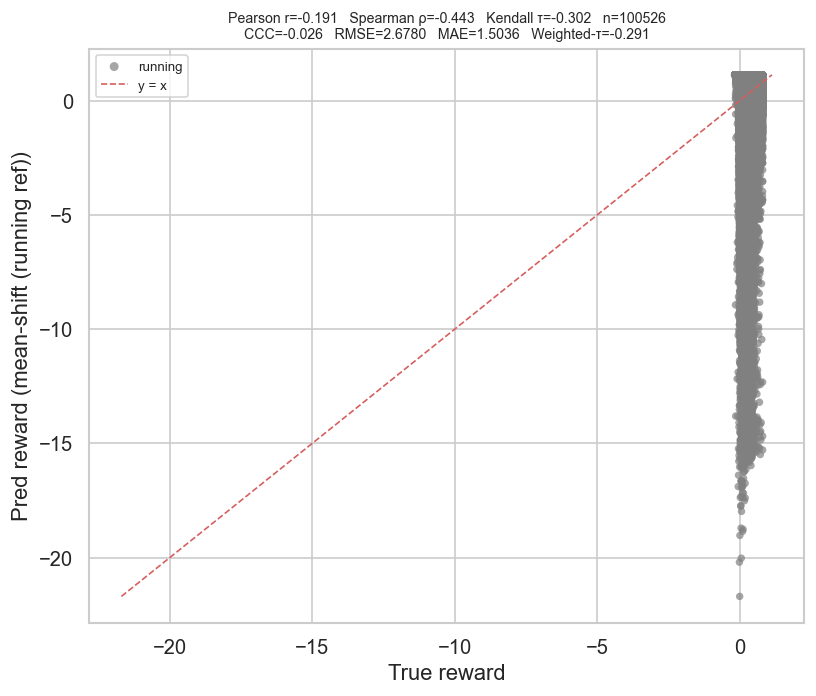

(<Figure size 840x720 with 1 Axes>,
 <Axes: title={'center': 'Pearson r=-0.191   Spearman ρ=-0.443   Kendall τ=-0.302   n=100526\nCCC=-0.026   RMSE=2.6780   MAE=1.5036   Weighted-τ=-0.291'}, xlabel='True reward', ylabel='Pred reward (mean-shift (running ref))'>)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau, weightedtau

STATUS_RUNNING = 4

STATUS_LABELS = {
    0: "arrived", 1: "collision", 2: "off_road", 3: "timeout",
    4: "running", 5: "teleported", 6: "removed",
}
STATUS_COLORS = {
    0: "steelblue", 1: "orange", 2: "crimson", 3: "mediumpurple",
    4: "gray",      5: "gold",   6: "saddlebrown",
}


# ── helper metrics ─────────────────────────────────────────────────────────────

def ccc(x, y):
    """Lin's Concordance Correlation Coefficient."""
    mean_x, mean_y = np.mean(x), np.mean(y)
    var_x,  var_y  = np.var(x),  np.var(y)
    cov = np.cov(x, y, ddof=0)[0, 1]
    return (2 * cov) / (var_x + var_y + (mean_x - mean_y) ** 2)


def plot_test2(segments, reward_model, norm_on_running, matching_mean, matching_std, plot_status):
    all_transitions = [t for segment in segments for t in segment]

    true_rewards = np.array([t.true_reward  for t in all_transitions], dtype=np.float32)
    obs    = np.array([t.observation for t in all_transitions], dtype=np.float32)
    acts   = np.array([t.action      for t in all_transitions], dtype=np.float32)
    status = np.array([t.next_status for t in all_transitions], dtype=np.float32)
    done   = np.array([float(t.done) for t in all_transitions], dtype=np.float32)
    pred_rewards = reward_model.predict(obs, acts, status, done)

    # ── normalisation mask ────────────────────────────────────────────────────
    norm_mask = np.ones(len(all_transitions), dtype=bool)
    if norm_on_running:
        norm_mask = status[:, STATUS_RUNNING] == 1

    true_mean = np.mean(true_rewards[norm_mask])
    true_std  = np.std(true_rewards[norm_mask])
    pred_mean = np.mean(pred_rewards[norm_mask])
    pred_std  = np.std(pred_rewards[norm_mask])

    if matching_mean and matching_std:
        pred_rewards_norm = (pred_rewards - pred_mean) / pred_std * true_std + true_mean
    elif matching_mean:
        pred_rewards_norm = pred_rewards - pred_mean + true_mean
    else:
        pred_rewards_norm = pred_rewards

    # ── plot mask ─────────────────────────────────────────────────────────────
    terminal_status   = np.argmax(status, axis=1)
    plot_mask = np.isin(terminal_status, plot_status)

    pred_rewards_plot = pred_rewards_norm[plot_mask]
    true_rewards_plot = true_rewards[plot_mask]
    
    # ── correlations ──────────────────────────────────────────────────────────
    pr,  _ = pearsonr(true_rewards_plot, pred_rewards_plot)
    sr,  _ = spearmanr(true_rewards_plot, pred_rewards_plot)
    kt,  _ = kendalltau(true_rewards_plot, pred_rewards_plot)

    # ── new metrics ───────────────────────────────────────────────────────────
    ccc_val  = ccc(true_rewards_plot, pred_rewards_plot)
    rmse_val = np.sqrt(np.mean((pred_rewards_plot - true_rewards_plot) ** 2))
    mae_val  = np.mean(np.abs(pred_rewards_plot - true_rewards_plot))
    wt_val,  _ = weightedtau(true_rewards_plot, pred_rewards_plot)   # weighted Kendall


    # ── plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 6))

    for status_id, color in STATUS_COLORS.items():
        m = terminal_status[plot_mask] == status_id
        if not m.any():
            continue
        ax.scatter(
            true_rewards_plot[m], pred_rewards_plot[m],
            color=color, label=STATUS_LABELS[status_id],
            alpha=0.7, s=20, edgecolors="none",
        )

    lo = min(true_rewards_plot.min(), pred_rewards_plot.min())
    hi = max(true_rewards_plot.max(), pred_rewards_plot.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1, label="y = x")

    ref_tag  = "running ref" if norm_on_running else "all ref"
    norm_tag = (f"z-score ({ref_tag})"    if (matching_mean and matching_std) else
                f"mean-shift ({ref_tag})" if matching_mean else "raw")

    ax.set_xlabel("True reward")
    ax.set_ylabel(f"Pred reward ({norm_tag})")

    # ── two-line title: classic metrics + new metrics ─────────────────────────
    line1 = f"Pearson r={pr:.3f}   Spearman ρ={sr:.3f}   Kendall τ={kt:.3f}   n={len(all_transitions)}"
    line2 = f"CCC={ccc_val:.3f}   RMSE={rmse_val:.4f}   MAE={mae_val:.4f}   Weighted-τ={wt_val:.3f}"
    ax.set_title(f"{line1}\n{line2}", fontsize=8.5)

    ax.legend(fontsize=8, markerscale=1.2)
    plt.tight_layout()
    plt.show()

    return fig, ax


plot_test2(
    trajectories, 
    reward_models_list[0], 
    norm_on_running=True, 
    matching_mean=True, 
    matching_std=False,
    plot_status=[4], 
)

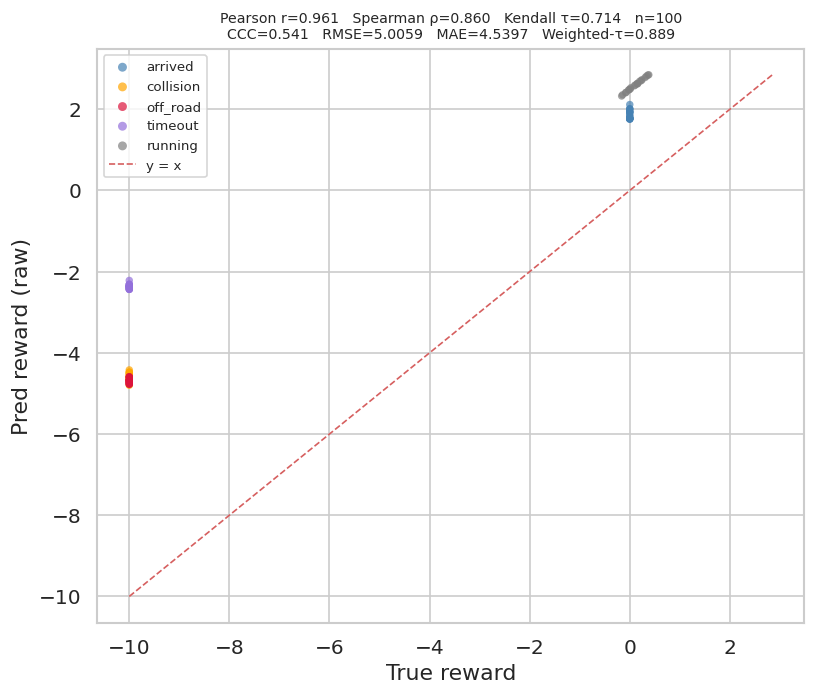

(<Figure size 840x720 with 1 Axes>,
 <Axes: title={'center': 'Pearson r=0.961   Spearman ρ=0.860   Kendall τ=0.714   n=100\nCCC=0.541   RMSE=5.0059   MAE=4.5397   Weighted-τ=0.889'}, xlabel='True reward', ylabel='Pred reward (raw)'>)

In [22]:
import pickle

SAVE_PATH = "/home/ricca/projects/sumo-human-feedback-rl/data_for_training/debug_dataset_seg1.pkl"

with open(SAVE_PATH, "rb") as f:
     data = pickle.load(f)

debug_segments = sum((data[s] for s in range(len(data))), [])


plot_test2(
    debug_segments, 
    reward_models_list[0], 
    norm_on_running=False, 
    matching_mean=False, 
    matching_std=False,
    plot_status=[0,1,2,3,4,5,6], 
)

In [ ]:
plot_test(trajectories, reward_models_list[-1], norm_on_running=False, matching_mean=False, matching_std=False)

In [ ]:
plot_test(trajectories, reward_models_list[-1], norm_on_running=False, matching_mean=False, matching_std=False)

In [ ]:
plot_test(trajectories, reward_models_list[-1], norm_on_running=False, matching_mean=False, matching_std=False)

In [9]:
seg_lens = [1, 5]
plot_scatter_all_models(trajectories, reward_models_list, seg_lens, normalize=True, robust=True)

KeyboardInterrupt: 

In [ ]:
import pickle

SAVE_PATH = "/home/ricca/projects/sumo-human-feedback-rl/data_for_training/debug_dataset_seg1.pkl"

with open(SAVE_PATH, "rb") as f:
     data = pickle.load(f)

debug_segments = sum((data[s] for s in range(len(data))), [])

plot_scatter_all_models(debug_segments, reward_models_list, seg_lens=[None], normalize=False, robust=False)

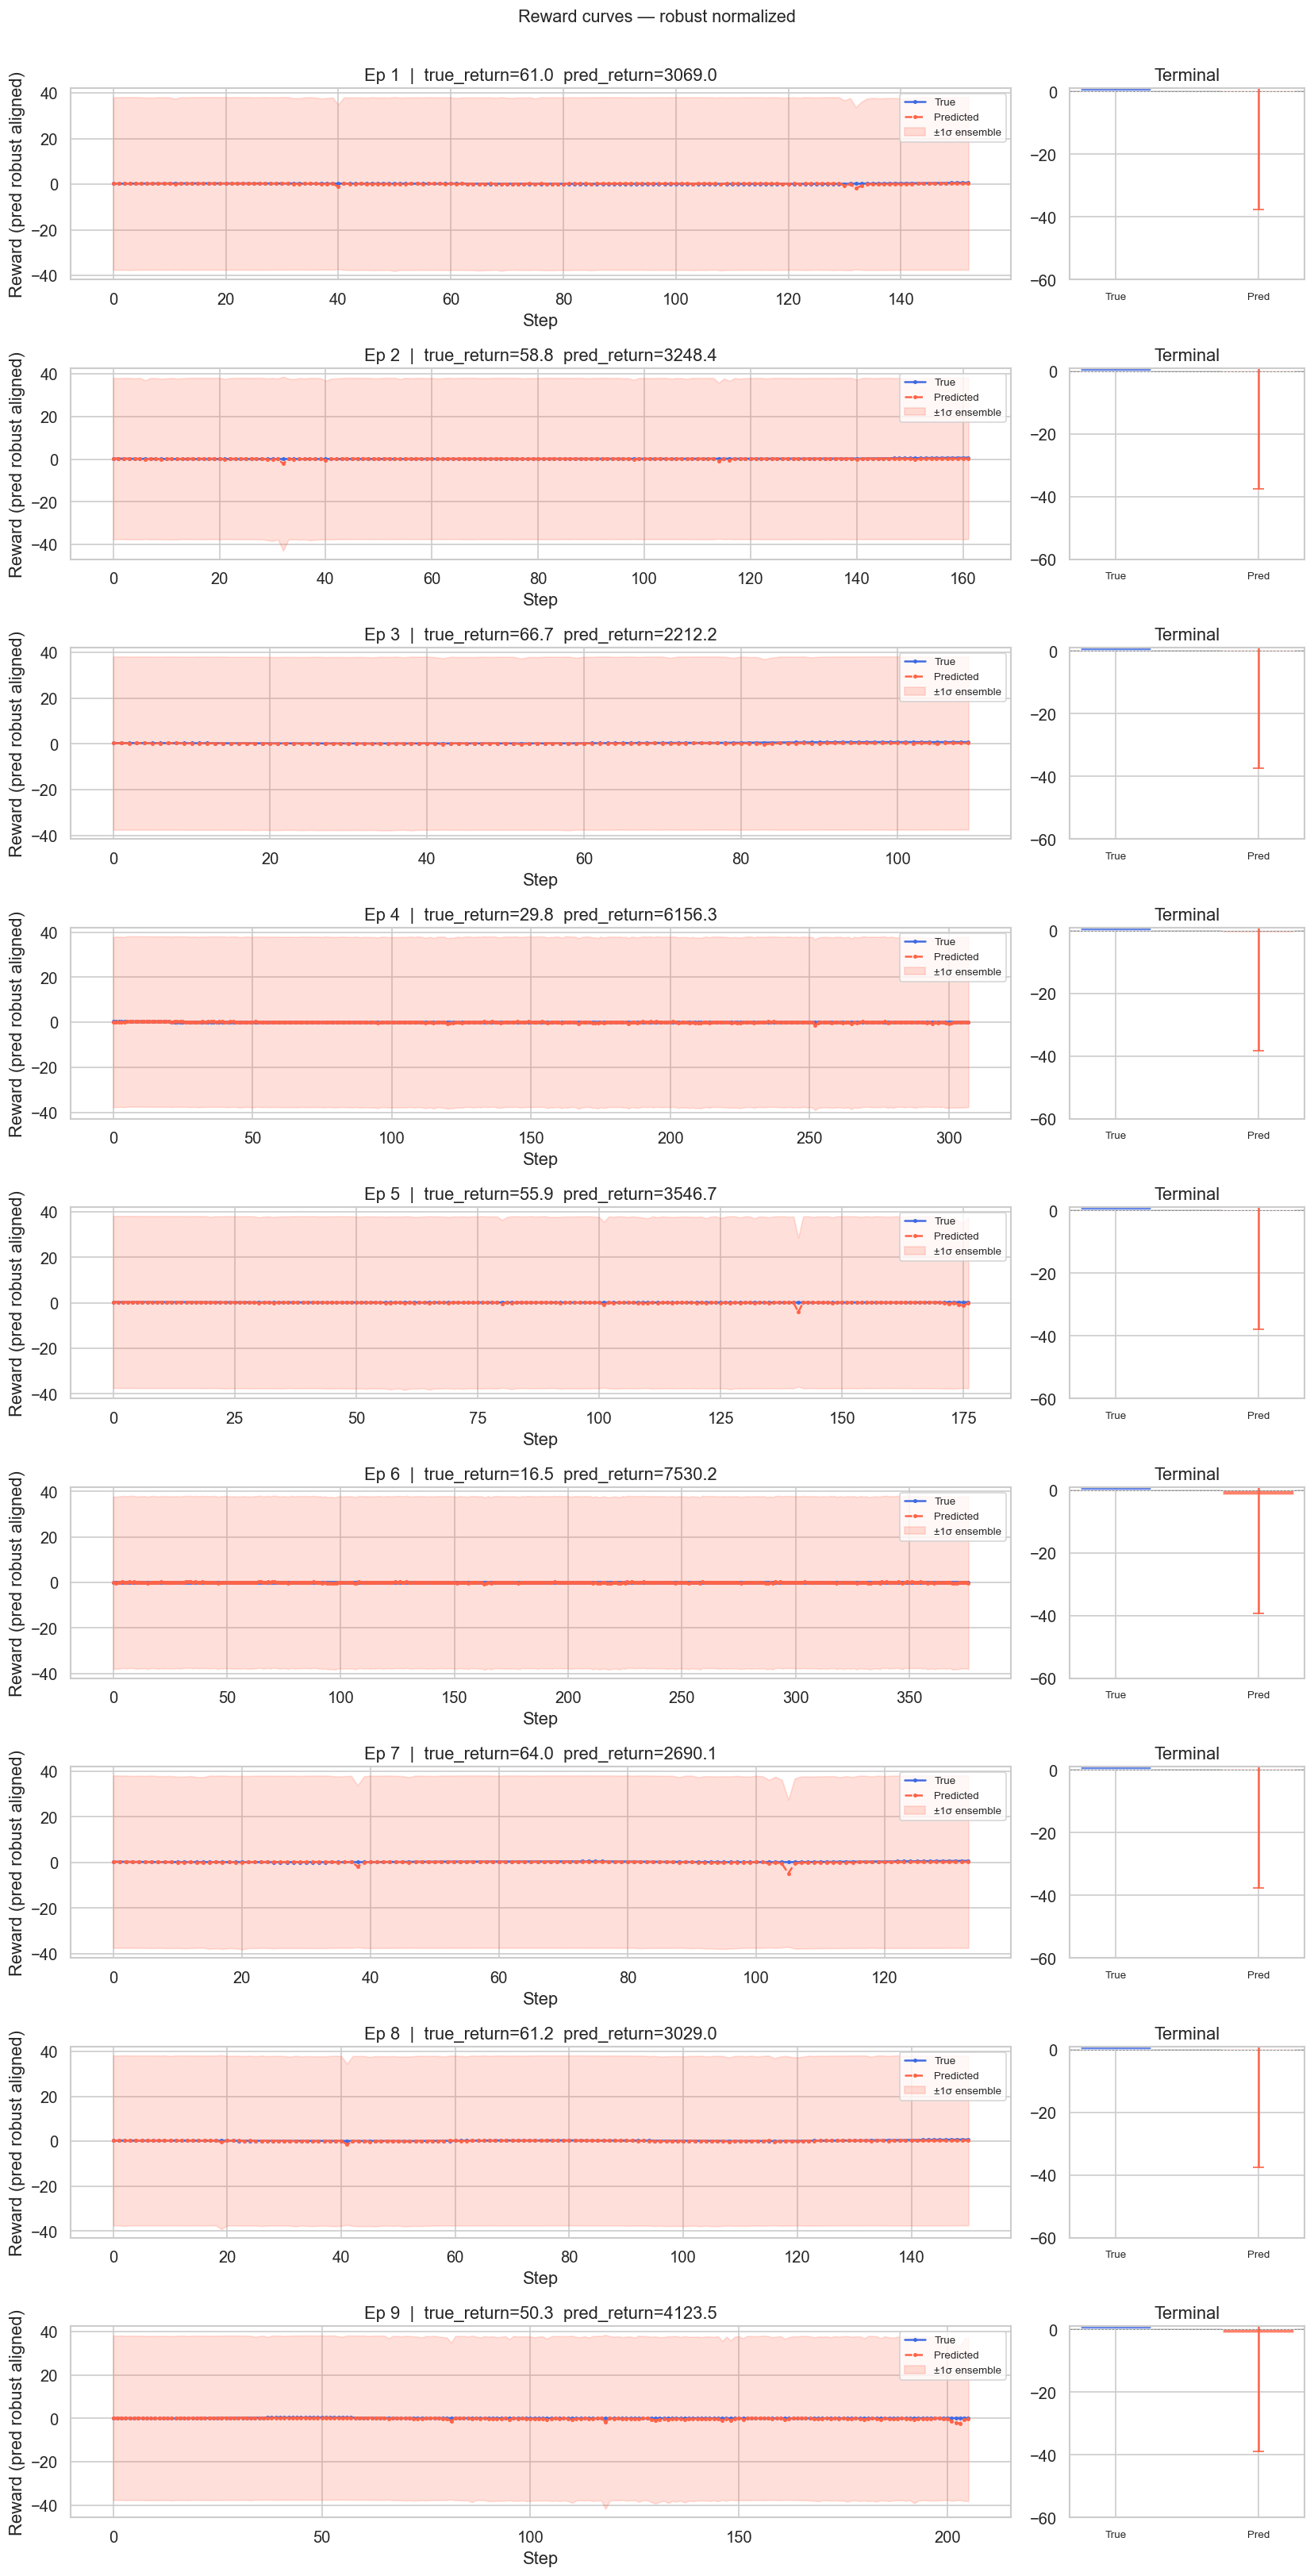

In [8]:
ID = -1
N_TRAJ = 10

plot_reward_curves(trajectories[0:N_TRAJ-1], reward_models_list[ID], normalize=True, robust=True)